# Hyunje Kim

Generally where $\ t_0 := 0, \ \begin{cases} \varphi_0 \in (0, \frac{\pi}{2}],\\ \varphi'_0 := 0,\\ \varphi''_0 := F_{\text{max}} \end{cases}$ with assumption $\Delta t \iff dt \in \mathbb{R}^{(0, 1)}$, application of the Velocity Verlet algorithm is described as such:

<br>

loop($t_0\rightarrow t_f$): # start loop

{


1)  $\varphi(t + \Delta t) = \varphi(t) + \Delta t \varphi(t) + \frac{\Delta t^2}{2m}F(t)$.

2)   $F(t + \Delta t) = m\varphi''(t + \Delta t)$.

3) $\varphi(t + \Delta t) = \varphi(t) + \frac{\Delta t}{2m} \Big( F(t + \Delta t) + F(t) \Big)$.

} # end loop @ $t=t_f$;

Define φ₀ | φ₀ € (0, π/2]
45
The difference in accuracy between the VV solution and the φ₀cos(ωt) approximation is most noticeable.
It is most noticeable that the φ₀cos(ωt) approximation is rather inaccurate as it now 'lags behind' the VV solution solution.
It seems that the φ₀cos(ωt) approximation is accurate enough for angle measurements less than or equal to 20°.
If φ₀ is  within (20°, 90°], especially φ₀ >> 20°, the inaccuracy of the φ₀cos(ωt) approximation increases  as t -> ∞.


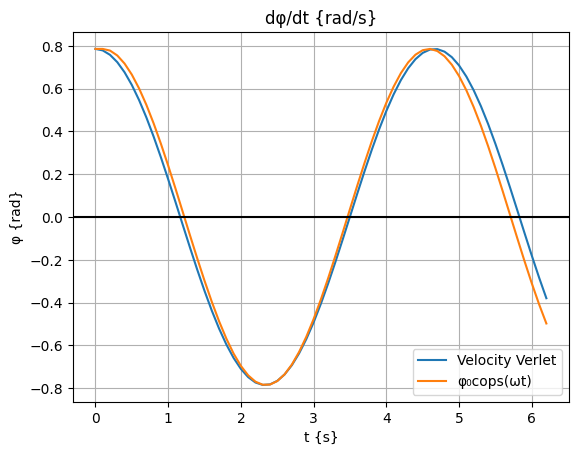

In [1]:
# @title
import math
import numpy as np
import matplotlib.pyplot as plt
#Constants
G = 9.8                                             #acceleration due to gravity {m/s²}
R = 5                                               #radius of elliptical path {m}
_ω = math.sqrt(G/R)                                 #natural frequency, ω
#Time Variables
_Δt = 0.1                                           #differential of time Δt
t = 0                                               #initial time t = t₀ = 0
tf = (math.pi*2) * 1                                #final time observance for, 1 complete rev.
#φ0 From User
_φ0 = input("Define φ₀ | φ₀ € (0, π/2]\n")          #φ₀ received
_φ0 = math.radians(float(_φ0))                      #ensures {° or rad} -> (rad), & restores as float type
#Initial Conditions
_φ = _φ0                                            #φ = φ₀
_φ1 = 0                                             #φ₀' = 0 b/c @ rest
_φ2 = -(G/R) * math.sin(_φ)                         #φ₀'' initialized | φ₀
#matplotlib arrays
time_sin_φ = []                                     #Domain for sin(φ) solution
pos_sin_φ = []                                      #Range for sin(φ) solution
time_φ = []                                         #Domain for φ approximation
pos_φ = []                                          #Range for φ approximation


#Loop Structure for VV:
while t < tf:
    time_sin_φ.append(t)                                #N-1th element of time stored as value of t
    pos_sin_φ.append(_φ)                                #N-1th element of φ stored as φ(t)
    #Velocity Verlet:
    _φ += (_Δt * _φ1) + (0.5 * _Δt * _Δt * _φ2)     #1: φ(t + Δt) = φ(t) + (Δt*φ'(t)) + (Δt²/2)φ''(t)
    _φ2_Δt = -(G/R) * math.sin(_φ)                  #2: φ''(t + Δt) = -(G/R)sin(φ(Δt))
    _φ1 += 0.5 * _Δt * (_φ2_Δt + _φ2)               #3: φ'(t + Δt) = φ'(t) + (Δt/2)(φ''(t + Δt) + φ''(t))
    #after verlet, prior next iteration
    _φ2 = _φ2_Δt                                    #φ''(t) = φ''(t + dt)
    t += _Δt                                        #increment t by Δt

#Initial Conditions for sin(φ) ≈ φ
t = 0
_φ_ = _φ0   #φ = φ₀cos(ωt), via sin(φ) ≈ φ
#Loop Structure for sin(φ) ≈ φ
while t < tf:
    time_φ.append(t)
    pos_φ.append(_φ_)
    _φ_ = _φ0 * math.cos(_ω * t)
    t += _Δt

#Feedback | φ₀
if 0 < _φ0 < math.radians(5):
    print("The difference in accuracy between the VV solution and the φ₀cos(ωt) approximation is noticeable.")
elif 0 < _φ0 <= math.radians(20):
    print("The difference in accuracy between the VV solution and the φ₀cos(ωt) approximation is still noticeable.")
    print("The φ₀cos(ωt) approximation seems to be slightly larger than the VV solution.")
    print("Hence, the φ₀cos(ωt) approximation is 'slightly ahead' of the sin(φ) solution.")
elif math.radians(20) < _φ0 <= math.radians(90):
    print("The difference in accuracy between the VV solution and the φ₀cos(ωt) approximation is most noticeable.")
    print("It is most noticeable that the φ₀cos(ωt) approximation is rather inaccurate as it now 'lags behind' the VV solution "
          "solution.")
    print("It seems that the φ₀cos(ωt) approximation is accurate enough for angle measurements less than or equal to 20°.")
    print("If φ₀ is  within (20°, 90°], especially φ₀ >> 20°, the inaccuracy of the φ₀cos(ωt) approximation increases "
          " as t -> ∞.")

#Formatting Data
plt.plot(time_sin_φ, pos_sin_φ, label='Velocity Verlet')
plt.plot(time_φ, pos_φ, label='φ₀cops(ωt)')
plt.title('dφ/dt {rad/s}')
plt.xlabel('t {s}')
plt.ylabel('φ {rad}')
plt.legend()
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.show()

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Spring Constants
m = 1                   #[kg]
k = 1                   #[N/m]
ω0 = math.sqrt(k / m)   #natural frequency, ω₀ = 1 {Hz}
#Time Parameters
Δt = 0.01               #differential of time
tf = (math.pi*2)* 10     #end of time observance
#Initial Conditions:
position0 = 1           #x₀=A|A as in amplitude
t = 0                #time

SHM(No Damping)

In [ ]:
pos = position0      #x=x₀
vel = 0
acc = -ω0**2 *pos
T = 0.5*m* vel**2    #Kinetic Energy
U = 0.5*k* pos**2    #Spring Potential Energy
#Plotting:
position = []
time = []
energy = []

while t < tf:
    position.append(pos)
    time.append(t)
    energy.append(T + U)
    #Velocity Verlet
    pos += (Δt*vel) + (0.5* Δt**2 *acc)
    acc_Δt = -ω0 ** 2 * math.sin(pos)
    vel += 0.5*Δt* (acc_Δt + acc)
    #prior to next iteration
    acc = acc_Δt
    T = 0.5*m* vel**2
    U = 0.5*k* pos**2
    t += Δt

Underdamping:

In [ ]:
β = 0.05     #weak damping constant
t1 = 0       #time

pos_under = position0
vel_under = 0
acc_under = -(2*β*vel_under + ω0**2 * pos_under)
T_under = 0.5*m* vel_under**2
U_under = 0.5*k* pos_under**2
#Plotting:
position1 = []
time1 = []
energy1 = []

while t1 < tf:
    position1.append(pos_under)
    time1.append(t1)
    energy1.append(T_under + U_under)
    #VV
    pos_under += (Δt * vel_under) + (0.5 * Δt**2 * acc_under)
    acc_under_Δt = -(2*β*vel_under + ω0**2 * math.sin(pos_under))
    vel_under += 0.5*Δt* (acc_under_Δt + acc_under)
    #prior next iteration
    acc_under = acc_under_Δt
    T_under = 0.5*m* vel_under**2
    U_under = 0.5*k* pos_under**2
    t1 += Δt

Overdamping:

In [ ]:
β1 = 2  # strong damping constant
t2 = 0

pos_over = position0
vel_over = 0
acc_over = -(2 * β1 * vel_over + ω0 ** 2 * pos_over)
T_over = 0.5*m* vel_over**2
U_over = 0.5 * k * pos_over ** 2

position2 = []
time2 = []
energy2 = []

while t2 < tf:
    position2.append(pos_over)
    time2.append(t2)
    energy2.append(T_over + U_over)

    pos_over += (Δt * vel_over) + (0.5 * Δt ** 2 * acc_over)
    acc_over_Δt = -(2 * β1 * vel_over + ω0 ** 2 * math.sin(pos_over))
    vel_over += 0.5 * Δt * (acc_over_Δt + acc_over)

    acc_over = acc_over_Δt
    T_over = 0.5*m* vel_over**2
    U_over = 0.5 * k * pos_over ** 2
    t2 += Δt

Critical Damping:

In [ ]:
β2 = ω0  # Critical damping constant
t3 = 0

pos_crit = position0
vel_crit = 0
acc_crit = -(2 * β2 * vel_crit + ω0 ** 2 * pos_crit)
T_crit = 0.5 * m * vel_crit ** 2
U_crit = 0.5 * k * pos_crit ** 2

position3 = []
time3 = []
energy3 = []

while t3 < tf:
    position3.append(pos_crit)
    time3.append(t3)
    energy3.append(T_crit + U_crit)

    pos_crit += (Δt * vel_crit) + (0.5 * Δt ** 2 * acc_crit)
    acc_crit_Δt = -(2 * β2 * vel_crit + ω0 ** 2 * math.sin(pos_crit))
    vel_crit += 0.5 * Δt * (acc_crit_Δt + acc_crit)

    acc_crit = acc_crit_Δt
    T_crit = 0.5 * m * vel_crit ** 2
    U_crit = 0.5 * k * pos_crit ** 2
    t3 += Δt

a) Graphs of Position & Energy w/ respect to Time

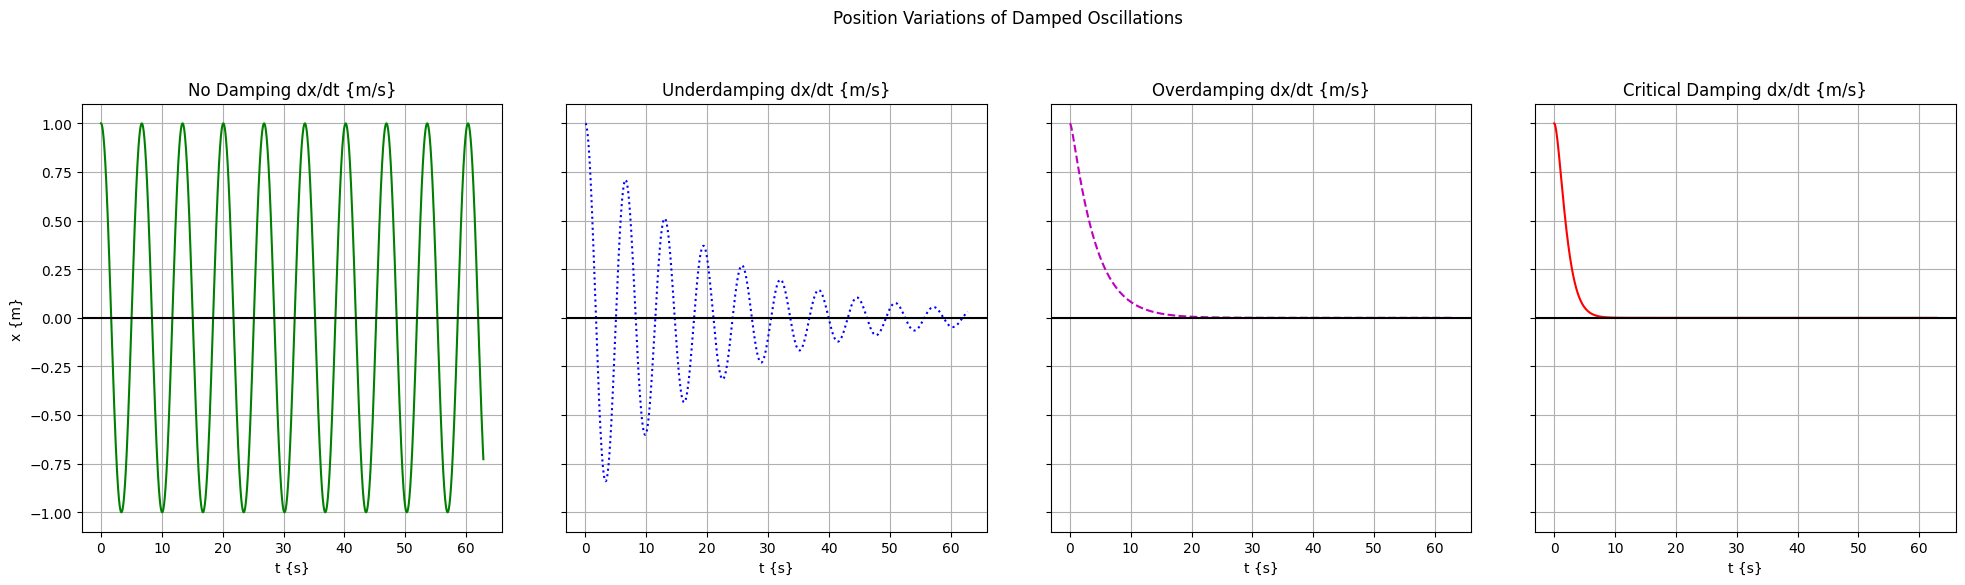

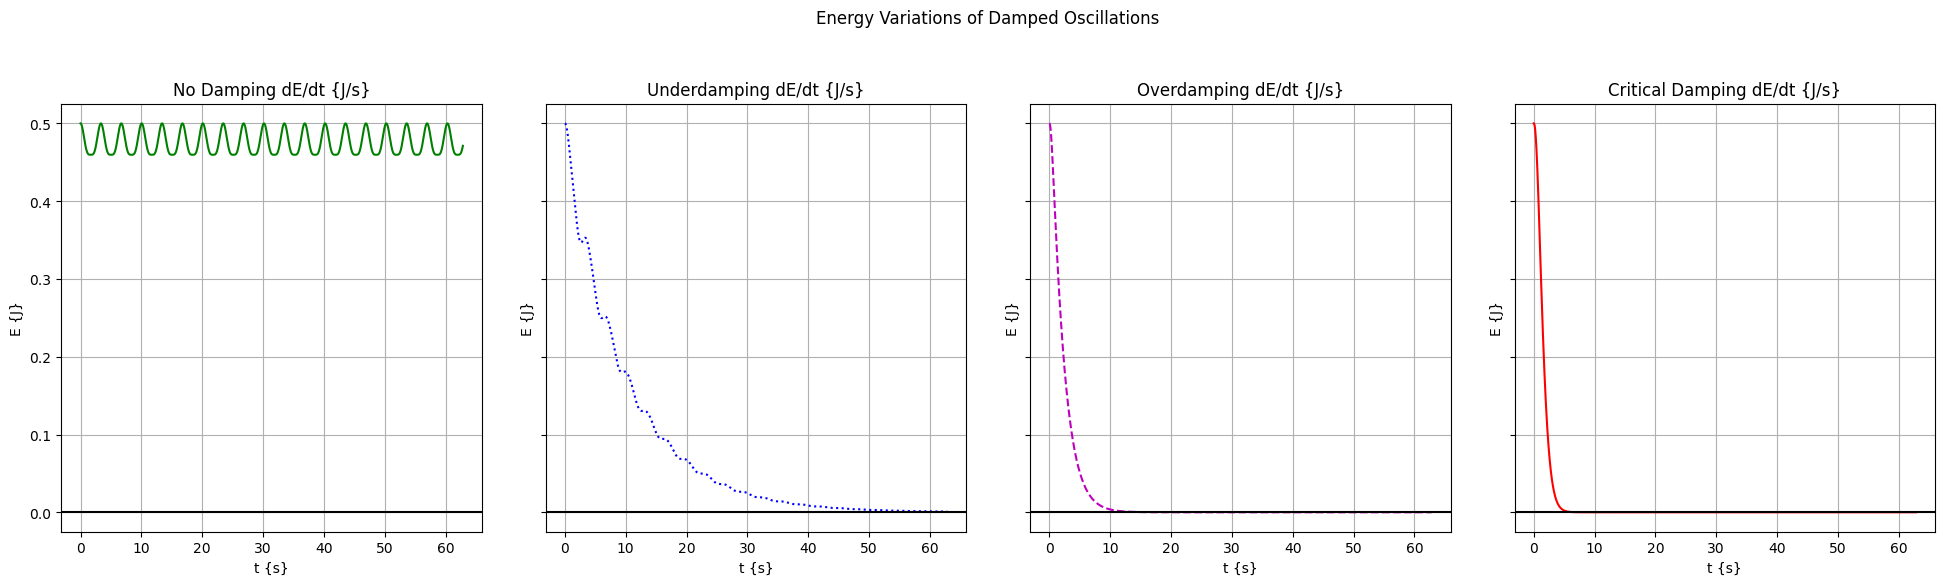

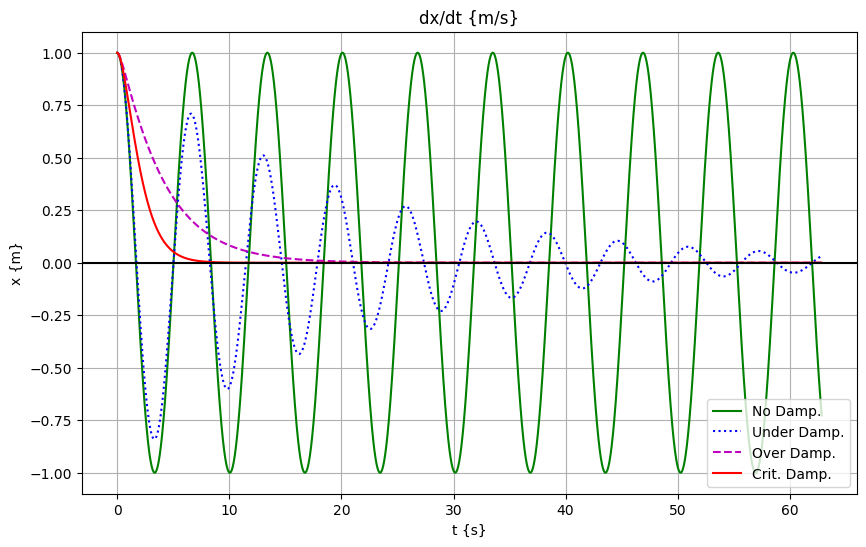

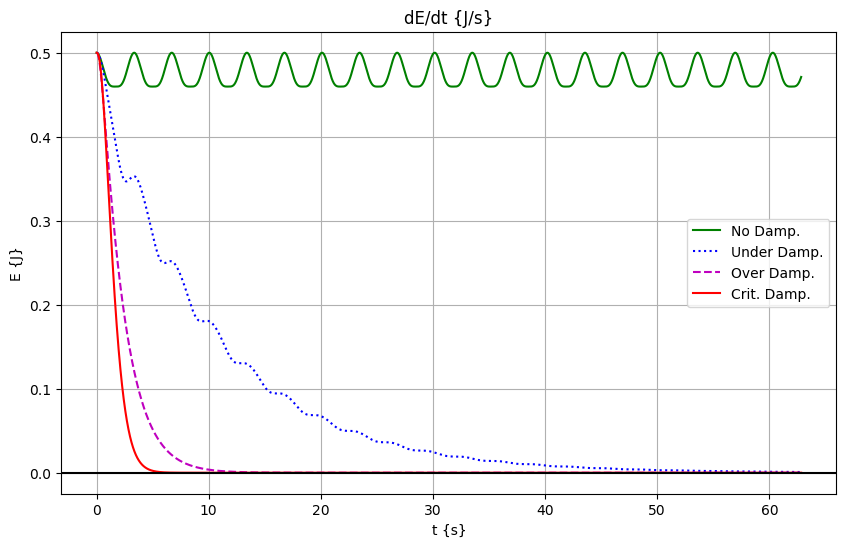

In [ ]:
#_______________________________Position Graphs_______________________________
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,6), sharex=True, sharey=True)
fig.suptitle('Position Variations of Damped Oscillations')
fig.tight_layout(pad=3.0)
ax1.plot(time, position, '-g')
ax1.set_title('No Damping dx/dt {m/s}')
ax1.axhline(y=0, color='black')
ax1.grid(True)
ax1.set_xlabel('t {s}')
ax1.set_ylabel('x {m}')
ax2.plot(time1, position1, ':b')
ax2.set_title('Underdamping dx/dt {m/s}')
ax2.axhline(y=0, color='black')
ax2.grid(True)
ax2.set_xlabel('t {s}')
ax3.plot(time2, position2, '--m')
ax3.set_title('Overdamping dx/dt {m/s}')
ax3.axhline(y=0, color='black')
ax3.grid(True)
ax3.set_xlabel('t {s}')
ax4.plot(time3, position3, '-r')
ax4.set_title('Critical Damping dx/dt {m/s}')
ax4.axhline(y=0, color='black')
ax4.grid(True)
ax4.set_xlabel('t {s}')
plt.show()
#_______________________________Energy Graphs_______________________________
fig, (ax5, ax6, ax7, ax8) = plt.subplots(1, 4, figsize=(20,6), sharex=True, sharey=True)
fig.suptitle('Energy Variations of Damped Oscillations')
fig.tight_layout(pad=3.0)
ax5.plot(time, energy, '-g')
ax5.set_title('No Damping dE/dt {J/s}')
ax5.axhline(y=0, color='black')
ax5.grid(True)
ax5.set_xlabel('t {s}')
ax5.set_ylabel('E {J}')
ax6.plot(time1, energy1, ':b')
ax6.set_title('Underdamping dE/dt {J/s}')
ax6.axhline(y=0, color='black')
ax6.grid(True)
ax6.set_xlabel('t {s}')
ax6.set_ylabel('E {J}')
ax7.plot(time2, energy2, '--m')
ax7.set_title('Overdamping dE/dt {J/s}')
ax7.axhline(y=0, color='black')
ax7.grid(True)
ax7.set_xlabel('t {s}')
ax7.set_ylabel('E {J}')
ax8.plot(time3, energy3, '-r')
ax8.set_title('Critical Damping dE/dt {J/s}')
ax8.axhline(y=0, color='black')
ax8.grid(True)
ax8.set_xlabel('t {s}')
ax8.set_ylabel('E {J}')
plt.show()
#_______________________________Overlapping Graphs_______________________________
plt.figure(figsize=(10, 6))
plt.plot(time, position, '-g', label='No Damp.')
plt.plot(time1, position1, ':b', label='Under Damp.')
plt.plot(time2, position2, '--m', label='Over Damp.')
plt.plot(time3, position3, '-r', label='Crit. Damp.')
plt.title('dx/dt {m/s}')
plt.xlabel('t {s}')
plt.ylabel('x {m}')
plt.legend()
plt.legend(loc='best')
plt.grid(True, which='both')
plt.axhline(y=0, color='black')
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(time, energy, '-g', label='No Damp.')
plt.plot(time1, energy1, ':b', label='Under Damp.')
plt.plot(time2, energy2, '--m', label='Over Damp.')
plt.plot(time3, energy3, '-r', label='Crit. Damp.')
plt.title('dE/dt {J/s}')
plt.xlabel('t {s}')
plt.ylabel('E {J}')
plt.legend()
plt.legend(loc='best')
plt.grid(True, which='both')
plt.axhline(y=0, color='black')
plt.show()

b)Graphs w/ Driven Damping Force

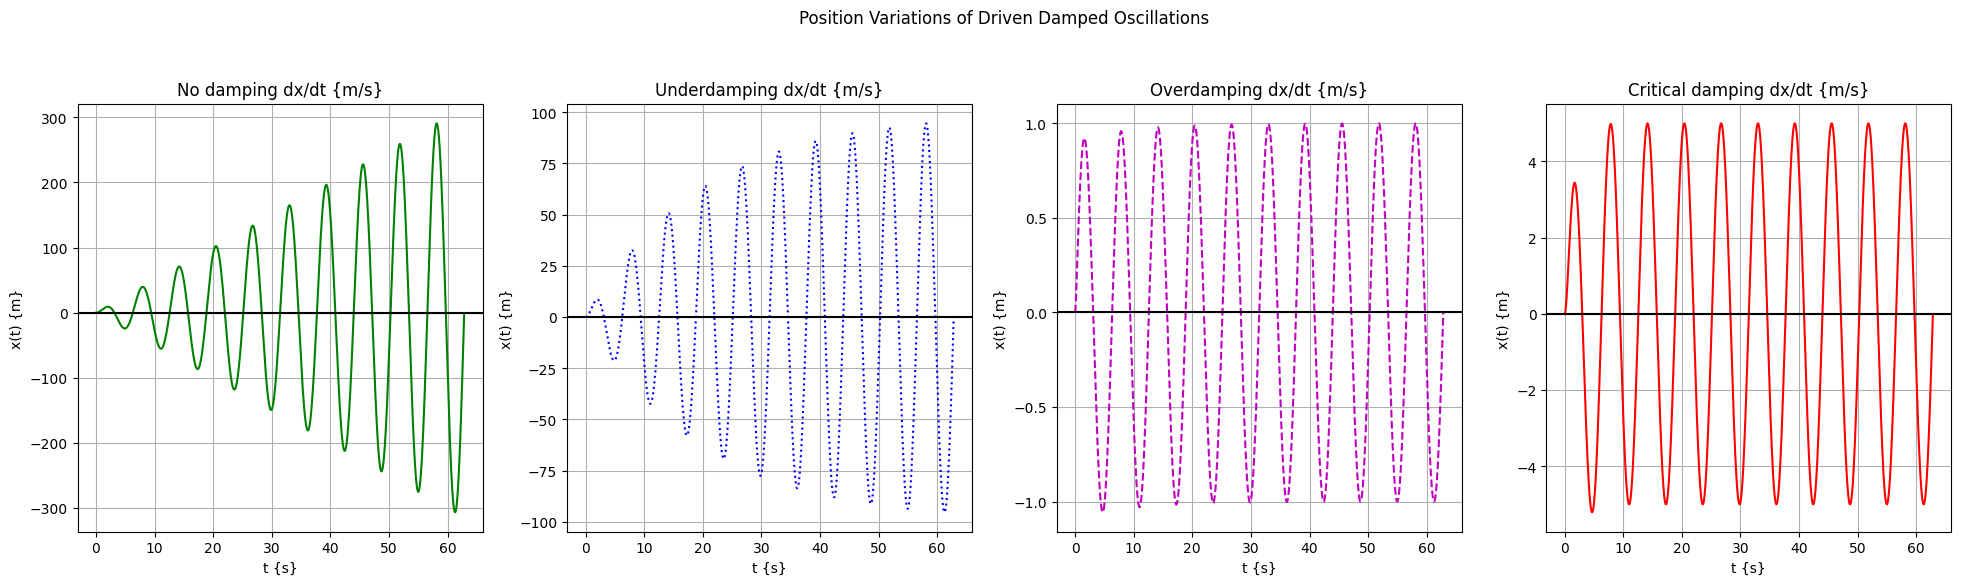

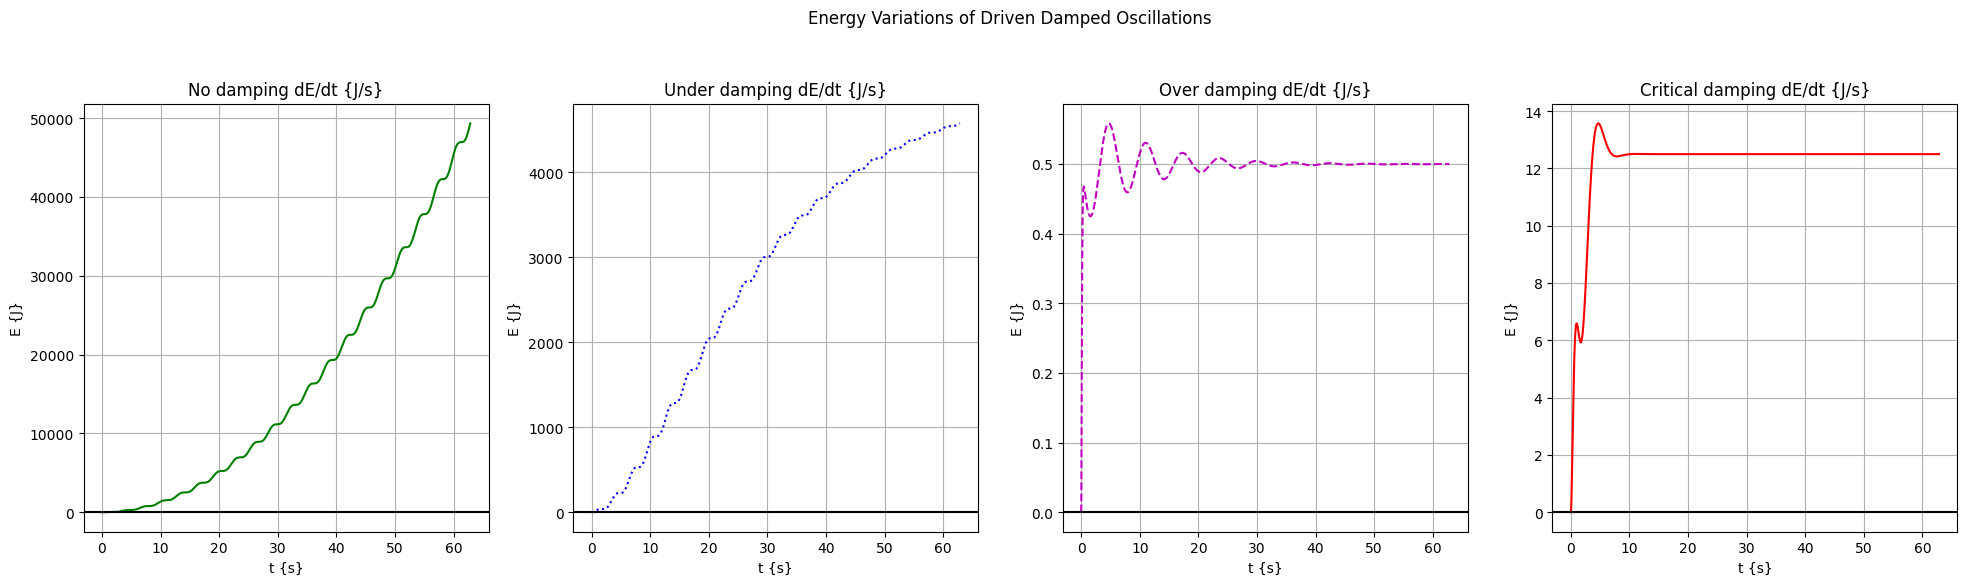

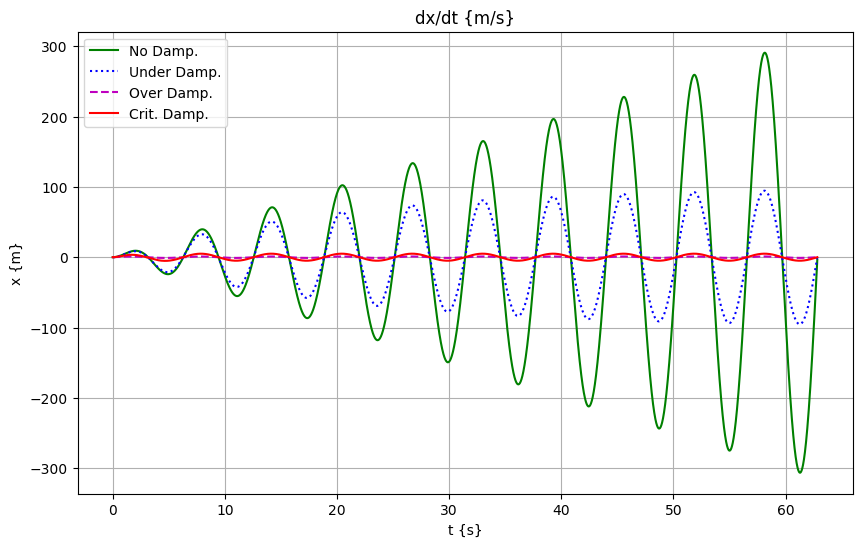

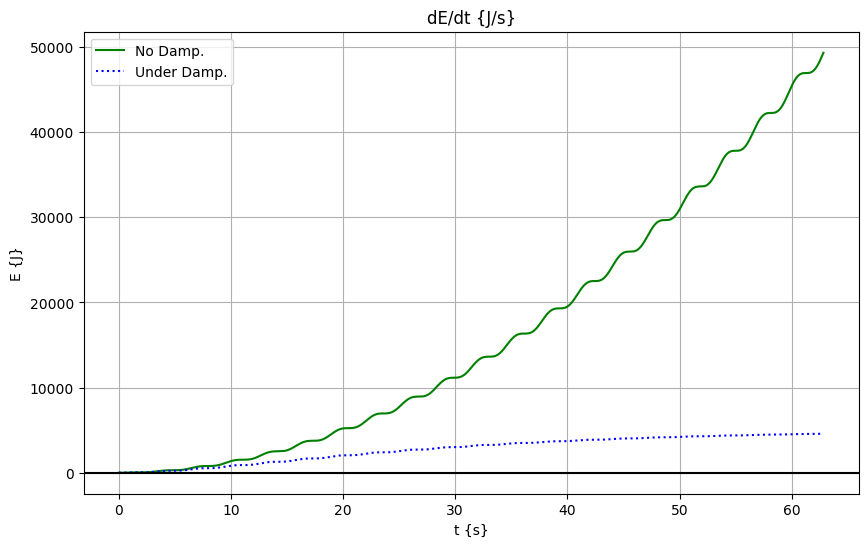

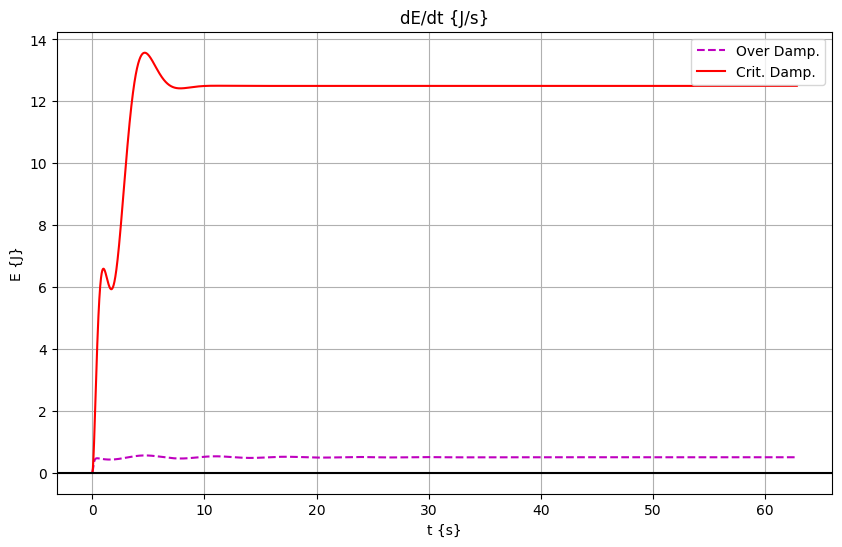

In [ ]:
# ______________________________Driven SHM______________________________
ω = ω0
t_driven = 0
f0 = 10                              #f₀, force amplitude
force = f0 * math.cos(ω * t_driven) #f(t) = f₀cos(ω₀t)
# initial assignment:
x_driven = 0
v_driven = 0
a_driven = force - ω ** 2 * x_driven
T_driven = 0.5 * m * v_driven**2
U_driven = 0.5 * k * x_driven**2
# Plotting:
pos_driven = []
time_driven = []
energy_driven = []
while t_driven < tf:
    pos_driven.append(x_driven)
    time_driven.append(t_driven)
    energy_driven.append(T_driven + U_driven)
    #VV
    x_driven += (Δt * v_driven) + (0.5 * Δt ** 2 * a_driven)
    force = f0 * math.cos(ω * t_driven)
    a_Δt = force - ω ** 2 * x_driven
    v_driven += 0.5 * Δt * (a_Δt + a_driven)
    # prior next iteration
    T_driven = 0.5 * m * v_driven**2
    U_driven = 0.5 * k * x_driven ** 2
    a_driven = a_Δt
    t_driven += Δt
# ______________________________Driven Weak Damped Oscillator______________________________
β_under_driven = ω / 20  # weak damping constant
t_under_driven = 0
force_weak = f0 * math.cos(ω * t_under_driven)
#initial assignment:
x_under = 0
v_under = 0
a_under = force_weak - (2 * β_under_driven * v_under + ω ** 2 * x_under)
T_under_driven = 0.5 * m * v_under**2
U_under_driven = 0.5 * k * x_under**2
# Plotting:
pos_under_driven = []
time_under_driven = []
energy_under_driven = []
while t_under_driven < tf:
    pos_under_driven.append(x_under)
    time_under_driven.append(t_under_driven)
    energy_under_driven.append(T_under_driven + U_under_driven)
    #VV
    x_under += (Δt * v_under) + (0.5 * Δt ** 2 * a_under)
    force_weak = f0 * math.cos(ω * t_under_driven)
    a_under_Δt = force_weak - (2 * β_under_driven * v_under + ω ** 2 * x_under)
    v_under += 0.5 * Δt * (a_under_Δt + a_under)
    #prior next iteration
    T_under_driven = 0.5 * m * v_under**2
    U_under_driven = 0.5 * k * x_under ** 2
    a_under = a_under_Δt
    t_under_driven += Δt
#______________________________Driven Overdamped Oscillator______________________________
β_over_driven = ω * 5  # strong damping constant
t_over_driven = 0
force_over = f0 * math.cos(ω * t_over_driven)
#initial assignment:
x_over = 0  # Initial Position
v_over = 0
a_over = force_over - (2 * β_over_driven * v_over + ω ** 2 * x_over)
T_over_driven = 0.5 * m * v_over**2
U_over_driven = 0.5 * k * x_over**2
#Plotting:
pos_over_driven = []
time_over_driven = []
energy_over_driven = []
while t_over_driven < tf:
    pos_over_driven.append(x_over)
    time_over_driven.append(t_over_driven)
    energy_over_driven.append(T_over_driven + U_over_driven)
    #VV
    x_over += (Δt * v_over) + (0.5 * Δt ** 2 * a_over)
    force_over = f0 * math.cos(ω * t_over_driven)
    a_over_Δt = force_over - (2 * β_over_driven * v_over + ω ** 2 * x_over)
    v_over += 0.5 * Δt * (a_over_Δt + a_over)
    #prior next iteration
    T_over_driven = 0.5 * m * v_over**2
    U_over_driven = 0.5 * k * x_over ** 2
    a_over = a_over_Δt
    t_over_driven += Δt
#______________________________Driven Critically-damped Oscillator______________________________
β_crit_driven = ω  #critical damping constant
t_crit_driven = 0
force_crit = f0 * math.cos(ω * t_crit_driven)
#initial assignment:
x_crit = 0  # Initial Position
v_crit = 0
a_crit = force_crit - (2 * β_crit_driven * v_crit + ω ** 2 * x_crit)
T_crit_driven = 0.5 * m * v_crit**2
U_crit_driven = 0.5 * k * x_crit**2
#Plotting:
pos_crit_driven = []
time_crit_driven = []
energy_crit_driven = []
while t_crit_driven < tf:
    pos_crit_driven.append(x_crit)
    time_crit_driven.append(t_crit_driven)
    energy_crit_driven.append(T_crit_driven + U_crit_driven)
    #VV
    x_crit += (Δt * v_crit) + (0.5 * Δt ** 2 * a_crit)
    force_crit = f0 * math.cos(ω * t_crit_driven)
    a_crit_Δt = force_crit - (2 * β_crit_driven * v_crit + ω ** 2 * x_crit)
    v_crit += 0.5 * Δt * (a_crit_Δt + a_crit)
    #prior next iteration
    T_crit_driven = 0.5 * m * v_crit**2
    U_crit_driven = 0.5 * k * x_crit ** 2
    a_crit = a_crit_Δt
    t_crit_driven += Δt
# _______________________________________________________________________________________________________
#b)Graphs w/ Driven Damping Force
#_______________________________Position Graphs_______________________________
fig, (ax9, ax10, ax11, ax12) = plt.subplots(1, 4, figsize=(20, 6), sharex=True)
fig.suptitle('Position Variations of Driven Damped Oscillations')
fig.tight_layout(pad=3.0)
ax9.plot(time_driven, pos_driven, '-g')
ax9.set_title('No damping dx/dt {m/s}')
ax9.set_xlabel('t {s}')
ax9.set_ylabel('x(t) {m}')
ax9.axhline(y=0, color='black')
ax9.grid(True)
ax10.plot(time_under_driven, pos_under_driven, ':b')
ax10.set_title('Underdamping dx/dt {m/s}')
ax10.set_xlabel('t {s}')
ax10.set_ylabel('x(t) {m}')
ax10.axhline(y=0, color='black')
ax10.grid(True)
ax11.plot(time_over_driven, pos_over_driven, '--m')
ax11.set_title('Overdamping dx/dt {m/s}')
ax11.set_xlabel('t {s}')
ax11.set_ylabel('x(t) {m}')
ax11.axhline(y=0, color='black')
ax11.grid(True)
ax12.plot(time_crit_driven, pos_crit_driven, '-r')
ax12.set_title('Critical damping dx/dt {m/s}')
ax12.set_xlabel('t {s}')
ax12.set_ylabel('x(t) {m}')
ax12.axhline(y=0, color='black')
ax12.grid(True)
plt.show()
#_______________________________Energy Graphs_______________________________
fig, (ax13, ax14, ax15, ax16) = plt.subplots(1, 4, figsize=(20, 6), sharex=True)
fig.suptitle('Energy Variations of Driven Damped Oscillations')
fig.tight_layout(pad=3.0)
ax13.plot(time_driven, energy_driven, '-g')
ax13.set_title('No damping dE/dt {J/s}')
ax13.set_xlabel('t {s}')
ax13.set_ylabel('E {J}')
ax13.axhline(y=0, color='black')
ax13.grid(True)
ax14.plot(time_under_driven, energy_under_driven, ':b')
ax14.set_title('Under damping dE/dt {J/s}')
ax14.set_xlabel('t {s}')
ax14.set_ylabel('E {J}')
ax14.axhline(y=0, color='black')
ax14.grid(True)
ax15.plot(time_over_driven, energy_over_driven, '--m')
ax15.set_title('Over damping dE/dt {J/s}')
ax15.set_xlabel('t {s}')
ax15.set_ylabel('E {J}')
ax15.axhline(y=0, color='black')
ax15.grid(True)
ax16.plot(time_crit_driven, energy_crit_driven, '-r')
ax16.set_title('Critical damping dE/dt {J/s}')
ax16.set_xlabel('t {s}')
ax16.set_ylabel('E {J}')
ax16.axhline(y=0, color='black')
ax16.grid(True)
plt.show()
#_______________________________Overlapping Graphs_______________________________
plt.figure(figsize=(10, 6))
plt.plot(time_driven, pos_driven, '-g', label='No Damp.')
plt.plot(time_under_driven, pos_under_driven, ':b', label='Under Damp.')
plt.plot(time_over_driven, pos_over_driven, '--m', label='Over Damp.')
plt.plot(time_crit_driven, pos_crit_driven, '-r', label='Crit. Damp.')
plt.title('dx/dt {m/s}')
plt.xlabel('t {s}')
plt.ylabel('x {m}')
plt.legend()
plt.legend(loc='best')
plt.grid(True, which='both')
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(time_driven, energy_driven, '-g', label='No Damp.')
plt.plot(time_under_driven, energy_under_driven, ':b', label='Under Damp.')
plt.title('dE/dt {J/s}')
plt.xlabel('t {s}')
plt.ylabel('E {J}')
plt.legend()
plt.legend(loc='best')
plt.grid(True, which='both')
plt.axhline(y=0, color='black')
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(time_over_driven, energy_over_driven, '--m', label='Over Damp.')
plt.plot(time_crit_driven, energy_crit_driven, '-r', label='Crit. Damp.')
plt.title('dE/dt {J/s}')
plt.xlabel('t {s}')
plt.ylabel('E {J}')
plt.legend()
plt.legend(loc='best')
plt.grid(True, which='both')
plt.axhline(y=0, color='black')
plt.show()


Under the presence of a driving force, an oscillator with no damping (β = 0) does not undergo simple harmonic motion. Instead the period after each cycle increases gradually over time, which is expected considering there is no damping. Thus there is no reduction to the magnitude of the driving force over time, leading to the increasing variances of cyclic periods. This also explains the energy measurement of the driven undamped oscillator, as energy measurements are increasing, almost 'exponentially', over time. The driven undamped oscillator(β << ω₀) behaves rather similarly, although the position variances are not as great in magnitude compared to the undamped oscillator. Hence, the energy measurements exhibit a 'logarithmic' growth.

As for greater damped oscillators, a driving force affecting an overdamped oscillator(β >> ω₀) actually causes pseudo-harmonic motion. Initially it may not appear to be so, however after 30 seconds or so the position measurements exhibit a familiar harmonic pattern with amplitude A ≈ 1{m}. As for its energy measurements, it is unlike the undamped and underdamped oscillators. Intially, the energy measurement 'spikes' up. Over time, it seems to dissipate into maintaining a measurement of ≈ 0.5 {J} . Similarly, the critical damped oscillator(β = ω₀) exhibits the pseudo-harmonic pattern but much earlier on, after the first cycle or so. To which, we see position variances with amplitude A ≈ 4.5{m}. Energy measurements 'spike' up like the driven overdamped oscillator except it reaches a higher output and maintains roughly more than ≈ 12 {J} as it dissipates over time.

Overall, it seems to be that with the choice of our driving frequency(ω) and natural frequency(ω₀) both being 1{Hz}, an oscillator with little to no damping will undergo large position and energy variances with respect to time. However, it will not replicate harmonic motion and instead gradually increase its cyclic period. Whereas over- and critically damped osciallators will replicate harmonic motion, which depends on how close the damping constant (β) is to the natural frequency(ω₀).  

c)Runge-Kutta Algorithm

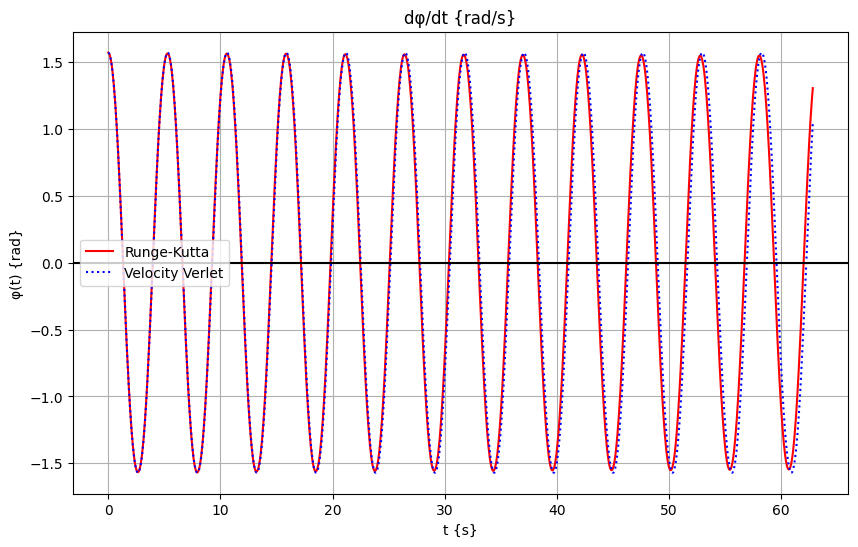

In [ ]:
#Constants
g = 9.8
R = 5
#Time Parameters
Δt = 0.001               #differential of time
tf = (math.pi*2)* 10     #end of time observance
#initial angle
φ0 = math.pi/2
#________________________________________Runge Kutta________________________________________
#Function Modeling Path w/ respect to time, considering position and velocity
t = np.linspace(0, tf, 1000)
position0 = φ0
velocity0 = 0                       #φ₀' = 0 b/c @ rest
y = [position0, velocity0]          #vector y = [φ₀, φ₀']
#Function that receives [t, φ₀, φ₀'] --> provides [φ', φ'']
def model(t,y):
    solution = [y[1], -(g / R) * math.sin(y[0])]
    return solution

motion = solve_ivp(model, [0,tf], y0 = y, t_eval = t)
#________________________________________Velocity Verlet________________________________________
t_vv = 0       #initial time t = t₀ = 0
#Initial Conditions:
φ = φ0
φ1 = 0                                #φ₀' = 0
φ2 = -(g / R) * math.sin(φ)           #φ₀'' initialized | φ₀

time_VV = []
pos_VV = []

while t_vv < tf:
    time_VV.append(t_vv)
    pos_VV.append(φ)
    #Velocity Verlet:
    φ += (Δt * φ1) + (0.5 * Δt ** 2 * φ2)     #1: φ(t + Δt) = φ(t) + (Δt*φ'(t)) + (Δt²/2)φ''(t)
    φ2_Δt = -(g/R) * math.sin(φ)               #2: φ''(t + Δt) = -(G/R)sin(φ(Δt))
    φ1 += 0.5 * Δt * (φ2_Δt + φ2)             #3: φ'(t + Δt) = φ'(t) + (Δt/2)(φ''(t + Δt) + φ''(t))
    #after verlet, prior next iteration
    φ2 = φ2_Δt                                 #φ''(t) = φ''(t + dt)
    t_vv += Δt
#________________________________________plot results________________________________________
plt.figure(figsize=(10, 6))
plt.plot(t, motion.y[0], '-r', label='Runge-Kutta')
plt.plot(time_VV, pos_VV, ':b', label='Velocity Verlet')
plt.title('dφ/dt {rad/s}')
plt.xlabel('t {s}')
plt.ylabel('φ(t) {rad}')
plt.legend(loc='best')
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.show()